In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import shapiro, mannwhitneyu

np.random.seed(42)


In [67]:
# Open one run to expore the data
df = pd.read_csv('results/power_data_Brave_run3.csv')

df

,Delta,Time,CPU_FREQUENCY_0,CPU_FREQUENCY_1,CPU_FREQUENCY_2,CPU_FREQUENCY_3,CPU_FREQUENCY_4,CPU_FREQUENCY_5,CPU_FREQUENCY_6,CPU_FREQUENCY_7,...,CPU_USAGE_3,CPU_USAGE_4,CPU_USAGE_5,CPU_USAGE_6,CPU_USAGE_7,SYSTEM_POWER (Watts),TOTAL_MEMORY,TOTAL_SWAP,USED_MEMORY,USED_SWAP
0,0,1771995342618,3204,3204,3204,3204,3204,3204,3204,3204,...,50.000000,0.000000,0.000000,0.000000,0.000000,4.540333,8589934592,2147483648,5870764032,433127424
1,209,1771995342618,3204,3204,3204,3204,3204,3204,3204,3204,...,NaN,NaN,NaN,0.000000,0.000000,4.540333,8589934592,2147483648,5870764032,433127424
2,205,1771995342829,3204,3204,3204,3204,3204,3204,3204,3204,...,23.809525,4.761905,4.545455,0.000000,0.000000,4.540333,8589934592,2147483648,5870764032,433127424
3,209,1771995343035,3204,3204,3204,3204,3204,3204,3204,3204,...,28.571430,5.000000,5.000000,4.761905,4.545455,4.540333,8589934592,2147483648,5870764032,433127424
4,200,1771995343245,3204,3204,3204,3204,3204,3204,3204,3204,...,76.190475,22.727274,9.523809,9.523809,0.000000,4.772572,8589934592,2147483648,5838094336,433127424
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
870,200,1771995521993,3204,3204,3204,3204,3204,3204,3204,3204,...,10.526316,10.000000,19.047619,9.523809,4.761905,4.545659,8589934592,2147483648,5850447872,433127424
871,208,1771995522193,3204,3204,3204,3204,3204,3204,3204,3204,...,23.809525,0.000000,0.000000,0.000000,0.000000,4.472409,8589934592,2147483648,5851807744,433127424
872,201,1771995522402,3204,3204,3204,3204,3204,3204,3204,3204,...,19.047619,4.545455,0.000000,0.000000,0.000000,4.472409,8589934592,2147483648,5838798848,433127424
873,207,1771995522604,3204,3204,3204,3204,3204,3204,3204,3204,...,19.047619,4.761905,0.000000,4.761905,5.000000,4.472409,8589934592,2147483648,5835931648,433127424


In [68]:
# Example how the energy estimation was done in the EnergiBridge example provided to us

# If data from Apple (column SYSTEM_POWER (Watts)), compute energy using trapezoidal rule
if "SYSTEM_POWER (Watts)" in df.columns:
    system_power_key = "SYSTEM_POWER (Watts)"
    system_energy = np.trapezoid(df[system_power_key], df['Time']/1000)
    print('Total system energy: {} J'.format(system_energy))
    print(f'Total time: {df['Delta'].sum() / 1000} seconds')
    print(f'Another time: {(df['Time'].max() - df['Time'].min()) / 1000} seconds')
    


Total system energy: 1026.7058282129967 J
Total time: 179.303 seconds
Another time: 180.194 seconds


In [69]:
system_power_key = "SYSTEM_POWER (Watts)"

browsers = ['Brave', 'Chrome', 'Firefox']
runs = 30

data = {
    'Brave': [],
    'Chrome': [],
    'Firefox': []
}

for browser in browsers:
    for run in range(1, runs + 1):
        df = pd.read_csv(f'results/power_data_{browser}_run{run}.csv')

        system_energy = np.trapezoid(df[system_power_key], df['Time']/1000)
        runtime = (df['Time'].max() - df['Time'].min()) / 1000

        data[browser].append(system_energy / runtime)
        # print('Total system energy: {} J'.format(system_energy))

data

{'Brave': [np.float64(5.478432221011078),
  np.float64(6.021363935082103),
  np.float64(5.697780326831064),
  np.float64(5.258310599436308),
  np.float64(5.727031922562554),
  np.float64(6.421888739665165),
  np.float64(6.482478818572742),
  np.float64(6.881064656284293),
  np.float64(5.721449832404139),
  np.float64(5.91421953088215),
  np.float64(6.643926122321772),
  np.float64(6.819634964989358),
  np.float64(6.306630905641349),
  np.float64(6.754155201057103),
  np.float64(6.498918641929149),
  np.float64(6.505929192301096),
  np.float64(6.395061896877522),
  np.float64(6.4836296805543565),
  np.float64(6.582089460710488),
  np.float64(5.109002328020225),
  np.float64(5.877017010449355),
  np.float64(4.915806110599129),
  np.float64(5.865682731887909),
  np.float64(5.4164848721859045),
  np.float64(5.348031650424634),
  np.float64(4.887973474699543),
  np.float64(5.72734521896082),
  np.float64(4.69372987341816),
  np.float64(5.725466461895185),
  np.float64(5.853362475229758)],
 

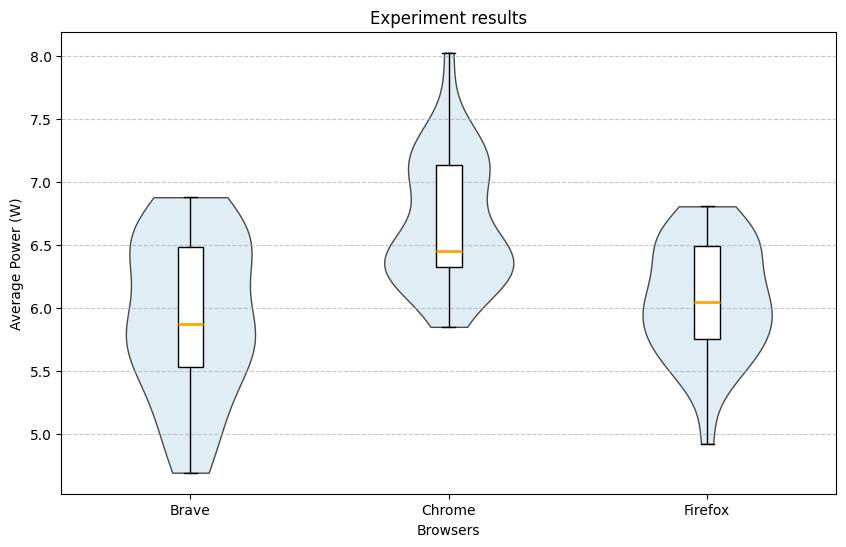

In [70]:
visual_data = [data['Brave'], data['Chrome'], data['Firefox']]

labels = ['Brave', 'Chrome', 'Firefox']

fig, ax = plt.subplots(figsize=(10, 6))

# showmedians=False because we let the Box Plot handle the median line
parts = ax.violinplot(visual_data, showmeans=False, showmedians=False, showextrema=False)

# Optional: Styling the violins
for pc in parts['bodies']:
    pc.set_facecolor('#D4E6F1')
    pc.set_edgecolor('black')
    pc.set_alpha(0.7)

# widths: makes the box plot thin enough to fit inside the violin
# patch_artist: allows us to fill the box with color
ax.boxplot(visual_data, widths=0.1, patch_artist=True,
           boxprops=dict(facecolor="white", color="black"),
           medianprops=dict(color="orange", linewidth=2),
           whiskerprops=dict(color="black"),
           capprops=dict(color="black"),
           flierprops=dict(marker='o', markersize=4, alpha=0.5))

ax.set_title('Experiment results')
ax.set_xlabel('Browsers')
ax.set_ylabel('Average Power (W)')
ax.set_xticks(np.arange(1, len(labels) + 1))
ax.set_xticklabels(labels)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
shapiro_p_value_brave = shapiro(data['Brave']).pvalue
shapiro_p_value_chrome = shapiro(data['Chrome']).pvalue
shapiro_p_value_firefox = shapiro(data['Firefox']).pvalue

print(f'Brave data is {'normal' if shapiro_p_value_brave >= 0.05 else 'NOT normal'} with p-value {shapiro_p_value_brave:.3f}')
print(f'Chrome data is {'normal' if shapiro_p_value_chrome >= 0.05 else 'NOT normal'} with p-value {shapiro_p_value_chrome:.3f}')
print(f'Firefox data is {'normal' if shapiro_p_value_firefox >= 0.05 else 'NOT normal'} with p-value {shapiro_p_value_firefox:.3f}')


Brave data is normal with p-value 0.203
Chrome data is NOT normal with p-value 0.026
Firefox data is normal with p-value 0.551


In [72]:
APPLY_BONFERRONI_CORRECTION = True
P_VALUE = 0.05

if APPLY_BONFERRONI_CORRECTION:
    P_VALUE = 0.05 / 3

u_value_brave_chrome, p_value_brave_chrome = mannwhitneyu(data['Brave'], data['Chrome'])
u_value_brave_firefox, p_value_brave_firefox = mannwhitneyu(data['Brave'], data['Firefox'])
u_value_chrome_firefox, p_value_chrome_firefox = mannwhitneyu(data['Chrome'], data['Firefox'])
# ttest_ind(data['Brave'], data['Firefox'], equal_var=False, alternative='two-sided')

print(f'The statistical test is Mann-Whitney U{' with Bonferroni correction' if APPLY_BONFERRONI_CORRECTION else ''}')
print(f'The difference between between Brave and Chrome is {'' if p_value_brave_chrome < P_VALUE else 'NOT' }statistically significant with p-value {p_value_brave_chrome:.3f}')
print(f'The difference between between Brave and Firefox is {'' if p_value_brave_firefox < P_VALUE else 'NOT '}statistically significant with p-value {p_value_brave_firefox:.3f}')
print(f'The difference between between Chrome and Firefox is {'' if p_value_chrome_firefox < P_VALUE else 'NOT '}statistically significant with p-value {p_value_chrome_firefox:.3f}')

The statistical test is Mann-Whitney U with Bonferroni correction
The difference between between Brave and Chrome is statistically significant with p-value 0.000
The difference between between Brave and Firefox is NOT statistically significant with p-value 0.340
The difference between between Chrome and Firefox is statistically significant with p-value 0.000


In [73]:
p_value_brave_chrome, p_value_chrome_firefox

(np.float64(0.0001584609391324261), np.float64(4.638965975341988e-05))

In [74]:
cles_brave_chrome = u_value_brave_chrome / (len(data['Brave']) * len(data['Chrome']))
cles_chrome_firefox = u_value_chrome_firefox / (len(data['Chrome']) * len(data['Firefox']))

print('Brave Chrome effect size calculation:')
print(f'Median difference: {np.median(data['Chrome']) - np.median(data['Brave']):.3f}')
print(f'Common language effect size: {cles_brave_chrome:.3f}')

print('')

print('Chrome Firefox effect size calculation:')
print(f'Median difference: {np.median(data['Chrome']) - np.median(data['Firefox']):.3f}')
print(f'Common language effect size: {cles_chrome_firefox:.3f}')



Brave Chrome effect size calculation:
Median difference: 0.579
Common language effect size: 0.216

Chrome Firefox effect size calculation:
Median difference: 0.405
Common language effect size: 0.807
